In [1]:
import sys
!{sys.executable} -m pip install sentence-transformers

In [3]:
from sentence_transformers import SentenceTransformer

print("sentence-transformers 載入成功")

sentence-transformers 載入成功


In [5]:
bert_ch = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [7]:
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer

# 1. 讀取你整理後的檔案
file_path = Path(r"C:\Users\uh52j\OneDrive\桌面\社群讀書會\RawdataLabled.csv")

df_labeled = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    sep=None,
    engine="python"
)

# 2. 只保留你需要的欄位
keep_cols = [
    "system_id",
    "artUrl",
    "artTitle",
    "artDate",
    "artContent",
    "bert_text",
    "label"
]

df_labeled = df_labeled[keep_cols].copy()

# 3. 建立 df_similar，直接使用整理好的 bert_text
df_similar = df_labeled[
    ["system_id", "artTitle", "artContent", "bert_text", "label"]
].copy()

# 4. 處理空值
df_similar["bert_text"] = df_similar["bert_text"].fillna("").astype(str)
df_similar["artTitle"] = df_similar["artTitle"].fillna("").astype(str)
df_similar["artContent"] = df_similar["artContent"].fillna("").astype(str)

# 5. 檢查結果
print(df_similar.shape)
df_similar.head()

(7616, 5)


,system_id,artTitle,artContent,bert_text,label
0,1,[難過]2020年12月步數不足,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,[難過]2020年12月步數不足2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都...,NaN
1,2,[難過]陽台又淹水了,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,[難過]陽台又淹水了大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門...,NaN
2,3,[閒聊]關於朋友這件事：（,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,[閒聊]關於朋友這件事：（不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是...,friend_related
3,4,[討論]大家都怎麼形容自己非常難過,小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來說去\n\n就一直只能\n“說我真...,[討論]大家都怎麼形容自己非常難過小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來...,NaN
4,5,Re:[討論]大家都怎麼形容自己非常難過,難過是什麼？\n為什麼要形容難過？\n形容難過形容的很好可以幹嘛？\n世界就會變好了嗎？\n...,Re:[討論]大家都怎麼形容自己非常難過難過是什麼？\n為什麼要形容難過？\n形容難過形容的...,NaN


In [9]:
df_similar_valid = df_similar.copy()

df_similar_valid["artContent"] = df_similar_valid["artContent"].fillna("").astype(str).str.strip()
df_similar_valid["bert_text"] = df_similar_valid["bert_text"].fillna("").astype(str).str.strip()

df_similar_valid = df_similar_valid[
    (df_similar_valid["artContent"] != "") &
    (df_similar_valid["bert_text"] != "")
].copy()

print("有效資料筆數：", df_similar_valid.shape)
df_similar_valid.head()

有效資料筆數： (7564, 5)


,system_id,artTitle,artContent,bert_text,label
0,1,[難過]2020年12月步數不足,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,[難過]2020年12月步數不足2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都...,NaN
1,2,[難過]陽台又淹水了,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,[難過]陽台又淹水了大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門...,NaN
2,3,[閒聊]關於朋友這件事：（,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,[閒聊]關於朋友這件事：（不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是...,friend_related
3,4,[討論]大家都怎麼形容自己非常難過,小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來說去\n\n就一直只能\n“說我真...,[討論]大家都怎麼形容自己非常難過小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來...,NaN
4,5,Re:[討論]大家都怎麼形容自己非常難過,難過是什麼？\n為什麼要形容難過？\n形容難過形容的很好可以幹嘛？\n世界就會變好了嗎？\n...,Re:[討論]大家都怎麼形容自己非常難過難過是什麼？\n為什麼要形容難過？\n形容難過形容的...,NaN


In [15]:
removed_rows = df_similar.loc[~df_similar.index.isin(df_similar_valid.index)]

print("被移除的筆數：", removed_rows.shape)
removed_rows.head()

被移除的筆數： (52, 5)


,system_id,artTitle,artContent,bert_text,label
119,": ""2021-02-04 14:10:00""}, {""cmtStatus"": ""推"", ""...",,,,NaN
120,NaN,,,,NaN
389,388,Re:R:[難過]自殺方案（更新於52樓）,,Re:R:[難過]自殺方案（更新於52樓）,NaN
609,", ""cmtContent"": "":就是讓人難以信任，還有就連az我們下單1"", ""cmtD...",2021/5/26 03:21,,44342.13961,NaN
1119,"}, {""cmtStatus"": ""→"", ""cmtPoster"": ""zero1000"",...",2021/10/14 01:09,,44483.04794,NaN


## *找相似文章*

In [11]:
texts = df_similar_valid["bert_text"].tolist()

embeddings_all = bert_ch.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

print("embedding shape:", embeddings_all.shape)

Batches:   0%|          | 0/473 [00:00<?, ?it/s]

embedding shape: (7564, 384)


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "朋友的事情"

query_embedding = bert_ch.encode([query])

similarity_scores = cosine_similarity(
    query_embedding,
    embeddings_all
).flatten()

top_indices = similarity_scores.argsort()[::-1][:10]

query_results = df_similar.iloc[top_indices].copy()
query_results["similarity"] = similarity_scores[top_indices]

query_results[["system_id", "artTitle", "similarity"]]

,system_id,artTitle,similarity
725,723,[心情]紓困貸款沒過..,0.713363
2980,2963,[難過]生病好不舒服QQ,0.652822
5060,5039,[難過]原來還有核心練到沒力的問題,0.632650
3385,3368,Re:[問題]被性騷擾了但對方強辯...,0.630443
1566,1556,[難過]新年不快樂,0.629092
1619,1606,[難過]求求你們不要再說露西亞有男朋友了,0.626559
187,186,[難過]GPA跟自己差不多的同學人生過的比較好..,0.626059
3955,3936,[難過]一覺醒來變天了：(,0.623686
2027,2013,[難過]iPhone哪代最深得你的心？,0.618825
3252,3235,[難過]九把刀會怎麼寫台北女子圖鑑?,0.618153


In [16]:
print("df_similar 筆數：", df_similar.shape)
print("embeddings_all shape：", embeddings_all.shape)

df_similar 筆數： (7616, 5)
embeddings_all shape： (7564, 384)


In [18]:
texts = df_similar_valid["bert_text"].tolist()

embeddings_all = bert_ch.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

print("df_similar_valid shape:", df_similar_valid.shape)
print("embeddings_all shape:", embeddings_all.shape)

Batches:   0%|          | 0/473 [00:00<?, ?it/s]

df_similar_valid shape: (7564, 5)
embeddings_all shape: (7564, 384)


In [40]:
queries = {
    "friend_negative": "朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單",
    "family_negative": "家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心",
    "love_negative": "男友分手，感情受傷，曖昧冷淡，讓我很難過",
    "work_negative": "工作壓力很大，主管同事讓我疲憊委屈",
    "pet_negative": "寵物離開，寵物生病，失去陪伴讓我很傷心"
}

In [42]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def search_similar_articles(query, model, embeddings, df_source, top_n=10):
    """
    query: 查詢句
    model: SentenceTransformer 模型，例如 bert_ch
    embeddings: 全部文章的 embeddings，例如 embeddings_all
    df_source: 與 embeddings 對齊的資料表，例如 df_similar_valid
    top_n: 取前幾篇相似文章
    """
    
    query_embedding = model.encode([query])
    
    similarity_scores = cosine_similarity(
        query_embedding,
        embeddings
    ).flatten()
    
    top_indices = similarity_scores.argsort()[::-1][:top_n]
    
    results = df_source.iloc[top_indices].copy()
    results["similarity"] = similarity_scores[top_indices]
    results["query"] = query
    
    return results[["system_id", "artTitle", "similarity", "query"]]

In [44]:
print(df_similar_valid.shape)
print(embeddings_all.shape)

assert len(df_similar_valid) == len(embeddings_all)

(7564, 5)
(7564, 384)


In [54]:
friend_results = search_similar_articles(
    query=queries["friend_negative"],
    model=bert_ch,
    embeddings=embeddings_all,
    df_source=df_similar_valid,
    top_n=10
)

family_results = search_similar_articles(
    query=queries["family_negative"],
    model=bert_ch,
    embeddings=embeddings_all,
    df_source=df_similar_valid,
    top_n=10
)

love_results = search_similar_articles(
    query=queries["love_negative"],
    model=bert_ch,
    embeddings=embeddings_all,
    df_source=df_similar_valid,
    top_n=10
)

work_results = search_similar_articles(
    query=queries["work_negative"],
    model=bert_ch,
    embeddings=embeddings_all,
    df_source=df_similar_valid,
    top_n=10
)

pet_results = search_similar_articles(
    query=queries["pet_negative"],
    model=bert_ch,
    embeddings=embeddings_all,
    df_source=df_similar_valid,
    top_n=10
)

In [56]:
friend_results

,system_id,artTitle,similarity,query
2,3,[閒聊]關於朋友這件事：（,0.814905,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
5209,5188,[心情]沒有朋友突然覺得很孤獨,0.730676,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
5204,5183,[心情]很久的好朋友離我遠去,0.722307,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
1065,1063,[難過]困擾好久的事,0.717637,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
3289,3272,[難過]我好崩潰,0.711535,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
6536,6498,[難過]被老朋友封鎖,0.711111,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
6014,5984,[難過]現實中完全沒有朋友,0.704238,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
117,118,[難過]分手之後沒朋友,0.693429,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
5778,5751,[難過]討厭的人一直出現,0.692969,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單
282,281,[心情]有朋友後又沒朋友的交友焦慮,0.683309,朋友疏遠我，絕交，封鎖，聚會不找我，讓我覺得傷心孤單


In [58]:
family_results

,system_id,artTitle,similarity,query
6756,6717,[難過]覺得自己上輩子到底欠父母多少,0.803861,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
1631,1618,[難過]病態人格的父母,0.776168,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
649,647,[難過]到最後我一無所有？,0.768806,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
1251,1248,[難過]到底有什麼問題,0.749182,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
6231,6196,[難過]為什麼我這麼不值得被愛？,0.735683,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
2568,2554,[難過]我爸都沒人願意照顧他..都丟給我一人顧,0.727962,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
918,916,[難過]不想回家,0.725906,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
528,527,[難過]情緒勒索之惡性循環,0.711082,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
1390,1387,[難過]外公走了...少了一個疼我的人,0.698514,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心
5802,5775,[難過]爸爸住院了,0.694671,家人父母給我壓力，媽媽爸爸不理解我，讓我覺得委屈傷心


In [68]:
pet_results

,system_id,artTitle,similarity,query
2006,1992,[難過]心愛的狗狗快過世了該怎麼調適心情,0.800434,寵物離開，寵物生病，失去陪伴讓我很傷心
380,379,[難過]寵物去世，心情是如何？,0.762104,寵物離開，寵物生病，失去陪伴讓我很傷心
7565,7521,[心情]狗狗走了家人不小心把遺物丟掉,0.756422,寵物離開，寵物生病，失去陪伴讓我很傷心
413,412,[難過]狗狗要安樂死了非常難過......,0.745008,寵物離開，寵物生病，失去陪伴讓我很傷心
788,786,[難過]寵物死掉了,0.739259,寵物離開，寵物生病，失去陪伴讓我很傷心
6209,6174,[難過]朋友的寵物走了,0.734046,寵物離開，寵物生病，失去陪伴讓我很傷心
7320,7276,[討論]會把愛轉移嗎?,0.728401,寵物離開，寵物生病，失去陪伴讓我很傷心
6693,6654,Re:[心情]今天走了,0.727394,寵物離開，寵物生病，失去陪伴讓我很傷心
5274,5253,[難過]我寵物快要死掉但是我沒心情上班,0.724301,寵物離開，寵物生病，失去陪伴讓我很傷心
7338,7294,[難過]寵物過世該怎麼調適心情,0.723845,寵物離開，寵物生病，失去陪伴讓我很傷心


In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

query_embeddings = {}

for label, query in queries.items():
    query_embeddings[label] = bert_ch.encode([query])

similarity_table = pd.DataFrame({
    "system_id": df_similar_valid["system_id"].values,
    "artTitle": df_similar_valid["artTitle"].values
})

for label, q_emb in query_embeddings.items():
    scores = cosine_similarity(q_emb, embeddings_all).flatten()
    similarity_table[label] = scores

similarity_table.head()

,system_id,artTitle,friend_negative,family_negative,love_negative,work_negative,pet_negative
0,1,[難過]2020年12月步數不足,0.153016,0.112888,0.090299,0.275992,0.136253
1,2,[難過]陽台又淹水了,0.339315,0.329568,0.290097,0.295350,0.378387
2,3,[閒聊]關於朋友這件事：（,0.814905,0.470043,0.504672,0.246064,0.518718
3,4,[討論]大家都怎麼形容自己非常難過,0.337854,0.488562,0.494428,0.295125,0.369918
4,5,Re:[討論]大家都怎麼形容自己非常難過,0.222577,0.287067,0.345309,0.258322,0.305739


In [62]:
score_cols = list(queries.keys())

similarity_table["best_match"] = similarity_table[score_cols].idxmax(axis=1)
similarity_table["best_score"] = similarity_table[score_cols].max(axis=1)

similarity_table[["system_id", "artTitle", "best_match", "best_score"]].head()

,system_id,artTitle,best_match,best_score
0,1,[難過]2020年12月步數不足,work_negative,0.275992
1,2,[難過]陽台又淹水了,pet_negative,0.378387
2,3,[閒聊]關於朋友這件事：（,friend_negative,0.814905
3,4,[討論]大家都怎麼形容自己非常難過,love_negative,0.494428
4,5,Re:[討論]大家都怎麼形容自己非常難過,love_negative,0.345309


In [64]:
similarity_table["best_match"].value_counts()

best_match
pet_negative       2303
work_negative      2068
friend_negative    1482
family_negative     944
love_negative       767
Name: count, dtype: int64

In [66]:
similarity_table["best_match"].value_counts(normalize=True).mul(100).round(2)

best_match
pet_negative       30.45
work_negative      27.34
friend_negative    19.59
family_negative    12.48
love_negative      10.14
Name: proportion, dtype: float64

In [70]:
threshold = 0.55

similarity_table["final_match"] = similarity_table["best_match"]

similarity_table.loc[
    similarity_table["best_score"] < threshold,
    "final_match"
] = "uncertain_or_other"

similarity_table["final_match"].value_counts()

final_match
uncertain_or_other    7073
work_negative          150
family_negative        113
love_negative           89
friend_negative         76
pet_negative            63
Name: count, dtype: int64

## *分類器*

In [17]:
label_check = df_similar_valid.copy()

label_check["has_label"] = (
    label_check["label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

print(label_check["has_label"].value_counts())

print("有人工 label：", label_check["has_label"].sum())
print("沒有人工 label：", (~label_check["has_label"]).sum())
print("總筆數：", len(label_check))

has_label
False    7495
True       69
Name: count, dtype: int64
有人工 label： 69
沒有人工 label： 7495
總筆數： 7564


In [75]:
# 1. 複製資料
df_train = df_labeled.copy()

# 2. 清理文字與標籤欄位
df_train["bert_text"] = df_train["bert_text"].fillna("").astype(str).str.strip()
df_train["label"] = df_train["label"].fillna("").astype(str).str.strip()

# 3. 只保留有文字、有標籤的資料
df_train = df_train[
    (df_train["bert_text"] != "") &
    (df_train["label"] != "")
].copy()

# 4. 檢查標籤分布
print("訓練資料筆數：", df_train.shape)
print(df_train["label"].value_counts())

訓練資料筆數： (69, 7)
label
friend_related    23
pet_related       21
family_related    18
other              7
Name: count, dtype: int64


In [77]:
from sentence_transformers import SentenceTransformer

bert_ch = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

texts = df_train["bert_text"].tolist()

X = bert_ch.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

y = df_train["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

X shape: (69, 384)
y shape: (69,)


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("訓練集筆數：", len(y_train))
print("測試集筆數：", len(y_test))

訓練集筆數： 55
測試集筆數： 14


In [81]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train, y_train)

print("Embedding 分類器訓練完成")

Embedding 分類器訓練完成


In [83]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.8571
                precision    recall  f1-score   support

family_related       0.80      1.00      0.89         4
friend_related       1.00      0.80      0.89         5
         other       0.00      0.00      0.00         1
   pet_related       1.00      1.00      1.00         4

      accuracy                           0.86        14
     macro avg       0.70      0.70      0.69        14
  weighted avg       0.87      0.86      0.86        14



<Figure size 800x600 with 0 Axes>

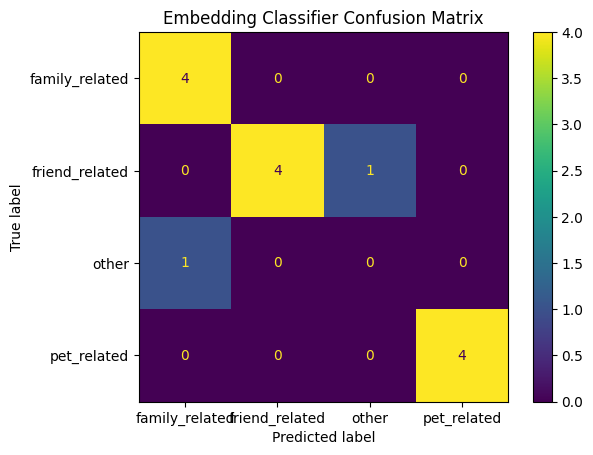

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = clf.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

plt.figure(figsize=(8, 6))
disp.plot(values_format="d")
plt.title("Embedding Classifier Confusion Matrix")
plt.show()

In [87]:
from sklearn.model_selection import cross_val_score
import numpy as np

clf_cv = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

acc_scores = cross_val_score(
    clf_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

f1_scores = cross_val_score(
    clf_cv,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("5-fold accuracy:", acc_scores)
print("平均 accuracy:", round(acc_scores.mean(), 4))
print("標準差:", round(acc_scores.std(), 4))

print("5-fold macro F1:", f1_scores)
print("平均 macro F1:", round(f1_scores.mean(), 4))
print("標準差:", round(f1_scores.std(), 4))

5-fold accuracy: [0.78571429 0.92857143 1.         0.92857143 0.84615385]
平均 accuracy: 0.8978
標準差: 0.0743
5-fold macro F1: [0.60972222 0.88888889 1.         0.9        0.80555556]
平均 macro F1: 0.8408
標準差: 0.131


In [89]:
final_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

final_clf.fit(X, y)

print("最終分類器訓練完成")

最終分類器訓練完成


In [91]:
# 建議使用有效文章資料表
df_predict = df_similar_valid.copy()

df_predict["bert_text"] = df_predict["bert_text"].fillna("").astype(str).str.strip()

texts_all = df_predict["bert_text"].tolist()

X_all = bert_ch.encode(
    texts_all,
    batch_size=16,
    show_progress_bar=True
)

df_predict["pred_label"] = final_clf.predict(X_all)

pred_probs = final_clf.predict_proba(X_all)
df_predict["pred_confidence"] = pred_probs.max(axis=1)

df_predict[["system_id", "artTitle", "pred_label", "pred_confidence"]].head()

Batches:   0%|          | 0/473 [00:00<?, ?it/s]

,system_id,artTitle,pred_label,pred_confidence
0,1,[難過]2020年12月步數不足,other,0.475771
1,2,[難過]陽台又淹水了,family_related,0.655331
2,3,[閒聊]關於朋友這件事：（,friend_related,0.965477
3,4,[討論]大家都怎麼形容自己非常難過,friend_related,0.500473
4,5,Re:[討論]大家都怎麼形容自己非常難過,friend_related,0.499263


In [93]:
df_predict["pred_label"].value_counts()

pred_label
friend_related    3309
other             2134
family_related    1737
pet_related        384
Name: count, dtype: int64

In [95]:
high_conf = df_predict[df_predict["pred_confidence"] >= 0.7].copy()

print("高信心文章數：", high_conf.shape[0])
print(high_conf["pred_label"].value_counts())
print(high_conf["pred_label"].value_counts(normalize=True).mul(100).round(2))

高信心文章數： 1624
pred_label
friend_related    785
other             426
family_related    307
pet_related       106
Name: count, dtype: int64
pred_label
friend_related    48.34
other             26.23
family_related    18.90
pet_related        6.53
Name: proportion, dtype: float64


In [97]:
low_conf = df_predict[df_predict["pred_confidence"] < 0.5].copy()

low_conf[["system_id", "artTitle", "pred_label", "pred_confidence"]].head(20)

,system_id,artTitle,pred_label,pred_confidence
0,1,[難過]2020年12月步數不足,other,0.475771
4,5,Re:[討論]大家都怎麼形容自己非常難過,friend_related,0.499263
6,7,[活動]penguin974-我以為,family_related,0.364132
9,10,[難過]明天是星期日了欸,other,0.354453
12,13,Re:[難過]貓與好人不重視主人託付也不用心的店家,friend_related,0.407312
14,15,[難過]生理期會想哭,family_related,0.355588
15,16,[心情]母豬今晚又失眠了想再發文,family_related,0.368817
17,18,[難過]小屁孩不言謝還走路像龜在爬擋本姑娘去路,friend_related,0.458572
20,21,[難過]酪梨放冰箱還是壞掉了,family_related,0.498836
22,23,[難過]被自己笨死,friend_related,0.447164


In [99]:
df_predict.to_csv(
    "embedding_classifier_predicted_articles.csv",
    index=False,
    encoding="utf-8-sig"
)

print("已輸出 embedding_classifier_predicted_articles.csv")

已輸出 embedding_classifier_predicted_articles.csv
